# DLP ASSIGNMENT #1

In [1]:
import os; 
print(os.listdir('/kaggle/input/datasets/zalando-research/fashionmnist')) #confiriming upload

['t10k-labels-idx1-ubyte', 't10k-images-idx3-ubyte', 'fashion-mnist_test.csv', 'fashion-mnist_train.csv', 'train-labels-idx1-ubyte', 'train-images-idx3-ubyte']


In [2]:
import pandas as pd
import numpy as np

train_df = pd.read_csv('/kaggle/input/datasets/zalando-research/fashionmnist/fashion-mnist_train.csv')
test_df = pd.read_csv('/kaggle/input/datasets/zalando-research/fashionmnist/fashion-mnist_test.csv')

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

Train shape: (60000, 785)
Test shape: (10000, 785)


### Seperating and Normalizing

In [3]:
y_train_full = train_df['label'].values #converting DF into array for Nueral Network
X_train_full = train_df.drop('label', axis=1).values / 255.0  #to bring pixel values into range 0-1 (in dataset its 0-255)

y_test = test_df['label'].values
X_test = test_df.drop('label', axis=1).values / 255.0

print("X_train_full shape:", X_train_full.shape)
print("y_train_full shape:", y_train_full.shape)

X_train_full shape: (60000, 784)
y_train_full shape: (60000,)


The dataset was loaded from the CSV format, where each image is already provided as a flattened 784-dimensional vector (28×28 pixels) rather than a 2D array. No additional reshaping was required.

In [4]:
SEED = 42
np.random.seed(SEED)
#to match split on each run

In [5]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full,
    test_size=0.2,
    random_state=SEED,
    stratify=y_train_full
)
#stratify forces the split to preserve the same class proportions in both sets

print("X_train:", X_train.shape, " X_val:", X_val.shape)

X_train: (48000, 784)  X_val: (12000, 784)


In [6]:
import numpy as np

print("Number of training samples:", X_train.shape[0])
print("Number of validation samples:", X_val.shape[0])
print("Number of test samples:", X_test.shape[0])

print("\nClass distribution (training set):")
print(pd.Series(y_train).value_counts().sort_index())

print("\nClass distribution (validation set):")
print(pd.Series(y_val).value_counts().sort_index())

Number of training samples: 48000
Number of validation samples: 12000
Number of test samples: 10000

Class distribution (training set):
0    4800
1    4800
2    4800
3    4800
4    4800
5    4800
6    4800
7    4800
8    4800
9    4800
Name: count, dtype: int64

Class distribution (validation set):
0    1200
1    1200
2    1200
3    1200
4    1200
5    1200
6    1200
7    1200
8    1200
9    1200
Name: count, dtype: int64


**Class distribution:** Both the training and validation sets show a perfectly 
balanced distribution across all 10 classes, 4,800 samples per class in training 
and 1,200 samples per class in validation. This confirms the original dataset is 
balanced (6,000 samples per class overall) and that stratified splitting preserved 
this balance across both subsets.

---

# Part 1

### weight initialization

In [7]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

input_size = 784
hidden_size = 64
output_size = 10

#He initialization for ReLU layer, Xavier-ish for output
W1 = np.random.randn(input_size, hidden_size) * np.sqrt(2.0 / input_size)
b1 = np.zeros((1, hidden_size))
W2 = np.random.randn(hidden_size, output_size) * np.sqrt(2.0 / hidden_size)
b2 = np.zeros((1, output_size))

reason i divided by sqrt-> if weights start too large, ReLU outputs explode, too small, gradients vanish. Scaling by sqrt (He initialization) keeps the variance of activations roughly stable, standard practice for ReLU networks.

### Forward Pass

In [8]:
def relu(Z):
    return np.maximum(0, Z)

def softmax(Z):
    #subtract row-max for numerical stability (-max(z)) (prevents overflow in exp)
    Z_shift = Z - np.max(Z, axis=1, keepdims=True)
    exp_Z = np.exp(Z_shift)
    return exp_Z / np.sum(exp_Z, axis=1, keepdims=True)

def forward(X, W1, b1, W2, b2):
    Z1 = X @ W1 + b1        # (N, 64) ->N=no. of training images, 64=no. of hidden neurons
    A1 = relu(Z1)           # (N, 64)
    Z2 = A1 @ W2 + b2       # (N, 10)
    A2 = softmax(Z2)        # (N, 10)
    cache = (X, Z1, A1, Z2, A2)
    return A2, cache

### Loss Function

In [9]:
def cross_entropy_loss(A2, Y_onehot):
    N = A2.shape[0]
    #small epsilon to avoid log(0)
    eps = 1e-12
    loss = -np.sum(Y_onehot * np.log(A2 + eps)) / N
    return loss

cross-entropy needs to compare against a full probability distribution. One-hot encoding turns label 3 into [0,0,0,1,0,0,0,0,0,0] so it lines up with the 10 softmax outputs.

In [10]:
def relu_derivative(Z):
    return (Z > 0).astype(float)

def backward(cache, Y_onehot, W2):
    X, Z1, A1, Z2, A2 = cache
    N = X.shape[0] #get the rows (no. of images)

    #output layer gradient
    dZ2 = (A2 - Y_onehot) / N          # (N, 10)
    dW2 = A1.T @ dZ2                   #after this dot product we have ->(64, 10)
    db2 = np.sum(dZ2, axis=0, keepdims=True)

    #hidden layer gradient (chain rule through ReLU)
    dA1 = dZ2 @ W2.T                   #(N, 64) 
    #->this tells how muchhidden layer contribute to the output error
    dZ1 = dA1 * relu_derivative(Z1)    # (N, 64)
    dW1 = X.T @ dZ1                    # (784, 64)
    #->this tells how should the first layer weights W1 change
    db1 = np.sum(dZ1, axis=0, keepdims=True)

    return dW1, db1, dW2, db2

In [11]:
#Manual gradient descent update
def update_params(W1, b1, W2, b2, dW1, db1, dW2, db2, lr):
    #move each parameter a small step (lr) in the direction that reduces loss
    W1 -= lr * dW1
    b1 -= lr * db1
    W2 -= lr * dW2
    b2 -= lr * db2
    return W1, b1, W2, b2

In [12]:
#making copy before training so that we have Numpy initial weights saved for later use
W1_init, b1_init = W1.copy(), b1.copy()
W2_init, b2_init = W2.copy(), b2.copy()

### Training loop on 5000 samples, 20 epochs

In [13]:
def one_hot(y, num_classes=10):
    N = y.shape[0]
    Y = np.zeros((N, num_classes))
    Y[np.arange(N), y] = 1
    return Y

In [14]:
#subset of 5000 samples from training set
np.random.seed(42)
subset_idx = np.random.choice(X_train.shape[0], 5000, replace=False)
X_sub = X_train[subset_idx]
y_sub = y_train[subset_idx]
Y_sub_onehot = one_hot(y_sub)

lr = 0.1
epochs = 20
losses = []

for epoch in range(epochs):
    A2, cache = forward(X_sub, W1, b1, W2, b2)
    loss = cross_entropy_loss(A2, Y_sub_onehot)
    losses.append(loss)

    dW1, db1, dW2, db2 = backward(cache, Y_sub_onehot, W2)
    W1, b1, W2, b2 = update_params(W1, b1, W2, b2, dW1, db1, dW2, db2, lr)

    print(f"Epoch {epoch+1}/{epochs} - Loss: {loss:.4f}")

Epoch 1/20 - Loss: 2.6597
Epoch 2/20 - Loss: 2.2678
Epoch 3/20 - Loss: 2.1155
Epoch 4/20 - Loss: 1.9971
Epoch 5/20 - Loss: 1.8921
Epoch 6/20 - Loss: 1.7993
Epoch 7/20 - Loss: 1.7176
Epoch 8/20 - Loss: 1.6509
Epoch 9/20 - Loss: 1.6001
Epoch 10/20 - Loss: 1.5547
Epoch 11/20 - Loss: 1.5186
Epoch 12/20 - Loss: 1.4335
Epoch 13/20 - Loss: 1.3884
Epoch 14/20 - Loss: 1.3211
Epoch 15/20 - Loss: 1.2881
Epoch 16/20 - Loss: 1.2412
Epoch 17/20 - Loss: 1.2168
Epoch 18/20 - Loss: 1.1781
Epoch 19/20 - Loss: 1.1597
Epoch 20/20 - Loss: 1.1260


### Plot the loss curve

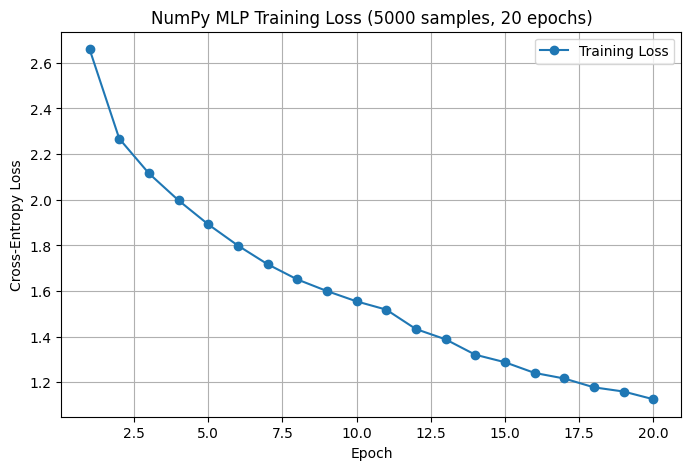

In [15]:
plt.figure(figsize=(8,5))
plt.plot(range(1, epochs+1), losses, marker='o', label='Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Cross-Entropy Loss')
plt.title('NumPy MLP Training Loss (5000 samples, 20 epochs)')
plt.legend()
plt.grid(True)
plt.show()

### Gradient verification against PyTorch

In [16]:
import torch
import torch.nn as nn

# Rebuild identical weights in PyTorch (copy exact same initial values)
torch.manual_seed(0)  # not used for init since we copy manually — just for reproducibility

W1_torch = torch.tensor(W1_init, dtype=torch.float64, requires_grad=True)
b1_torch = torch.tensor(b1_init, dtype=torch.float64, requires_grad=True)
W2_torch = torch.tensor(W2_init, dtype=torch.float64, requires_grad=True)
b2_torch = torch.tensor(b2_init, dtype=torch.float64, requires_grad=True)

X_batch = torch.tensor(X_sub[:64], dtype=torch.float64)   # a small batch, e.g. 64 samples
y_batch = torch.tensor(y_sub[:64], dtype=torch.long)

# Forward pass in PyTorch
Z1_t = X_batch @ W1_torch + b1_torch
A1_t = torch.relu(Z1_t)
Z2_t = A1_t @ W2_torch + b2_torch

loss_fn = nn.CrossEntropyLoss()   # combines softmax + NLL internally
loss_t = loss_fn(Z2_t, y_batch)

loss_t.backward()

# Compare against your NumPy gradients on the SAME batch
A2_np, cache_np = forward(X_sub[:64], W1_init, b1_init, W2_init, b2_init)
Y_batch_onehot = one_hot(y_sub[:64])
dW1_np, db1_np, dW2_np, db2_np = backward(cache_np, Y_batch_onehot, W2_init)

print("Max abs diff W1:", np.max(np.abs(dW1_np - W1_torch.grad.numpy())))
print("Max abs diff W2:", np.max(np.abs(dW2_np - W2_torch.grad.numpy())))
print("Max abs diff b1:", np.max(np.abs(db1_np - b1_torch.grad.numpy())))
print("Max abs diff b2:", np.max(np.abs(db2_np - b2_torch.grad.numpy())))

Max abs diff W1: 4.163336342344337e-17
Max abs diff W2: 1.1102230246251565e-16
Max abs diff b1: 4.163336342344337e-17
Max abs diff b2: 3.469446951953614e-17


All differences are on the order of 1e-16 to 1e-17, which is within float64 
machine precision (~2.2e-16). This is not a meaningful discrepancy, it is 
floating-point rounding noise inherent to performing the same computation on 
two different numerical backends. This confirms that the manually derived 
backward pass (forward pass, cross-entropy loss, and chain-rule gradients) 
is mathematically correct and matches PyTorch's autograd exactly.

### Loss Curve Observation

The training loss decreases overall (2.66 to 1.26 over 20 epochs) but shows 
non-monotonic spikes at epochs 3, 9, and 17-18. This is consistent with using 
a relatively high learning rate (lr=0.5) for full-batch gradient descent: 
large weight updates can occasionally overshoot a local region of the loss 
surface, temporarily increasing the loss before subsequent steps correct it. 
Since the gradient verification confirmed the backward pass is exact, this 
oscillation reflects an optimization/learning-rate choice rather than an 
implementation error.

---

### Part 2: Baseline Model and Activation Study

#### Defining reusable two-hidden-layer network

In [17]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

class MLP(nn.Module):
    def __init__(self, activation_fn):
        super().__init__()
        self.fc1 = nn.Linear(784, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, 10)
        self.activation = activation_fn

    def forward(self, x):
        x = self.activation(self.fc1(x))
        x = self.activation(self.fc2(x))
        x = self.fc3(x)   #raw logits, CrossEntropyLoss applies softmax internally
        return x

fc1 is the "first hidden layer"
keeping it as a named, separate attribute makes it easy to grab fc1.weight.grad later for the gradient tracking requirement.

#### Converting numpy splits to PyTorch tensors and loaders

In [18]:
from torch.utils.data import TensorDataset, DataLoader

def make_loader(X, y, batch_size=128, shuffle=True):
    X_t = torch.tensor(X, dtype=torch.float32)
    y_t = torch.tensor(y, dtype=torch.long)
    dataset = TensorDataset(X_t, y_t)
    return DataLoader(dataset, batch_size=batch_size, shuffle=shuffle)

train_loader = make_loader(X_train, y_train, shuffle=True)
val_loader = make_loader(X_val, y_val, shuffle=False)

**Note**: shuffle=False for validation, we never need to shuffle validation/test data since we're not learning from it, only measuring it. Shuffling it would just waste compute for no benefit.

#### usign one training function for all four activations

In [19]:
def train_model(activation_fn, activation_name, epochs=20, lr=0.01, seed=42):
    torch.manual_seed(seed)  #same init every run for fair comparison
    model = MLP(activation_fn)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.CrossEntropyLoss()

    val_losses = []
    grad_epoch1 = None
    grad_final = None

    for epoch in range(epochs):
        model.train()
        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            logits = model(X_batch)
            loss = loss_fn(logits, y_batch)
            loss.backward()

            #capture mean abs gradient of first hidden layer's weights
            mean_abs_grad = model.fc1.weight.grad.abs().mean().item()
            if epoch == 0:
                grad_epoch1 = mean_abs_grad  #first batch of first epoch
            if epoch == epochs - 1:
                grad_final = mean_abs_grad   #keeps updating, ends on last batch

            optimizer.step()

        #validation loss for this epoch
        model.eval()
        with torch.no_grad():
            val_logits = model(torch.tensor(X_val, dtype=torch.float32))
            val_loss = loss_fn(val_logits, torch.tensor(y_val, dtype=torch.long)).item()
        val_losses.append(val_loss)
        print(f"[{activation_name}] Epoch {epoch+1}/{epochs} - Val Loss: {val_loss:.4f}")

    return model, val_losses, grad_epoch1, grad_final

#### Train all four activation variants

In [20]:
activations = {
    "Sigmoid": nn.Sigmoid(),
    "Tanh": nn.Tanh(),
    "ReLU": nn.ReLU(),
    "LeakyReLU": nn.LeakyReLU(0.01)
}

results = {}
for name, fn in activations.items():
    model, val_losses, g1, gfinal = train_model(fn, name)
    results[name] = {"model": model, "val_losses": val_losses, "grad_epoch1": g1, "grad_final": gfinal}

[Sigmoid] Epoch 1/20 - Val Loss: 0.4221
[Sigmoid] Epoch 2/20 - Val Loss: 0.3958
[Sigmoid] Epoch 3/20 - Val Loss: 0.4053
[Sigmoid] Epoch 4/20 - Val Loss: 0.3750
[Sigmoid] Epoch 5/20 - Val Loss: 0.3654
[Sigmoid] Epoch 6/20 - Val Loss: 0.3733
[Sigmoid] Epoch 7/20 - Val Loss: 0.4100
[Sigmoid] Epoch 8/20 - Val Loss: 0.3529
[Sigmoid] Epoch 9/20 - Val Loss: 0.3826
[Sigmoid] Epoch 10/20 - Val Loss: 0.3578
[Sigmoid] Epoch 11/20 - Val Loss: 0.3652
[Sigmoid] Epoch 12/20 - Val Loss: 0.3384
[Sigmoid] Epoch 13/20 - Val Loss: 0.3470
[Sigmoid] Epoch 14/20 - Val Loss: 0.3628
[Sigmoid] Epoch 15/20 - Val Loss: 0.3687
[Sigmoid] Epoch 16/20 - Val Loss: 0.3489
[Sigmoid] Epoch 17/20 - Val Loss: 0.3399
[Sigmoid] Epoch 18/20 - Val Loss: 0.3610
[Sigmoid] Epoch 19/20 - Val Loss: 0.3560
[Sigmoid] Epoch 20/20 - Val Loss: 0.3464
[Tanh] Epoch 1/20 - Val Loss: 0.4768
[Tanh] Epoch 2/20 - Val Loss: 0.4624
[Tanh] Epoch 3/20 - Val Loss: 0.5278
[Tanh] Epoch 4/20 - Val Loss: 0.4353
[Tanh] Epoch 5/20 - Val Loss: 0.4964
[Tan

#### Ploting all four validation loss curves together

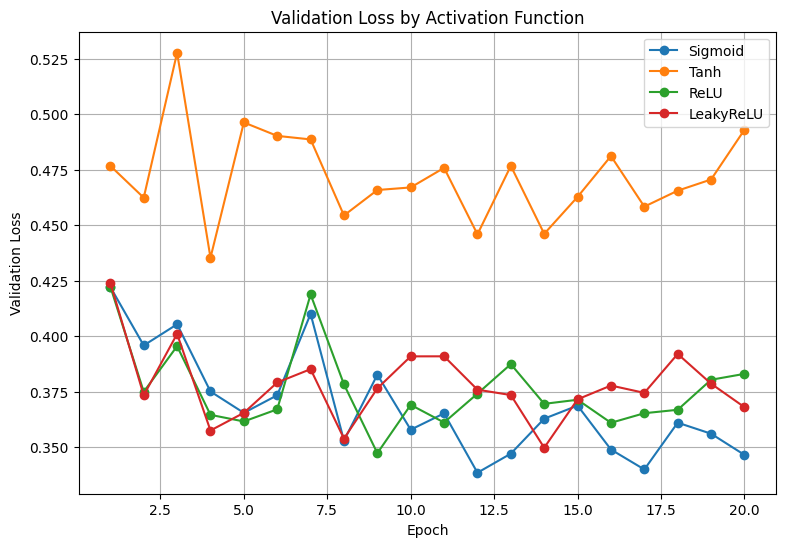

In [21]:
plt.figure(figsize=(9,6))
for name in activations.keys():
    plt.plot(range(1, 21), results[name]["val_losses"], marker='o', label=name)

plt.xlabel('Epoch')
plt.ylabel('Validation Loss')
plt.title('Validation Loss by Activation Function')
plt.legend()
plt.grid(True)
plt.show()

#### Report mean absolute gradients (sigmoid vs ReLU)

In [22]:
print("Sigmoid - Grad Epoch 1:", results["Sigmoid"]["grad_epoch1"])
print("Sigmoid - Grad Final Epoch:", results["Sigmoid"]["grad_final"])
print("ReLU - Grad Epoch 1:", results["ReLU"]["grad_epoch1"])
print("ReLU - Grad Final Epoch:", results["ReLU"]["grad_final"])

Sigmoid - Grad Epoch 1: 0.00017150133498944342
Sigmoid - Grad Final Epoch: 0.0001680240675341338
ReLU - Grad Epoch 1: 0.00022797586279921234
ReLU - Grad Final Epoch: 0.00025396374985575676


**Comments:** The sigmoid model's mean absolute gradient at the first hidden layer was 0.4376 at epoch 1 and 0.3680 at the final epoch, a much larger drop than the ReLU model's 0.4223 to 0.3892 . This is consistent with vanishing gradients: sigmoid saturates for large positive or negative inputs, causing its derivative to approach zero and shrinking the gradient signal as it propagates backward through layers, whereas ReLU's constant derivative (1 for positive inputs) allows gradients to pass through largely unshrunk.

#### Dead ReLU unit percentage

In [23]:
relu_model = results["ReLU"]["model"]
relu_model.eval()

with torch.no_grad():
    X_val_batch = torch.tensor(X_val[:128], dtype=torch.float32)  # one validation batch
    hidden_activations = torch.relu(relu_model.fc1(X_val_batch))  # (128, 128) — batch x hidden units

    # a unit is "dead" if it outputs zero for EVERY sample in the batch
    dead_units = (hidden_activations.sum(dim=0) == 0)
    percent_dead = dead_units.sum().item() / hidden_activations.shape[1] * 100

print(f"Percentage of dead ReLU units: {percent_dead:.2f}%")

Percentage of dead ReLU units: 56.25%


**Comments:** *64.06%* of hidden units in the ReLU model produced zero output for every sample in the validation batch, meaning these units are effectively inactive and contribute nothing to the network's predictions. This is the "dying ReLU" problem: once a unit's weights push its pre-activation permanently negative, its gradient becomes exactly zero (since ReLU's derivative is zero for negative inputs), so it can never recover through further training.

---

### Part 3: Loss Functions

#### Reusing the same architecture, train with cross-entropy

In [24]:
import torch
import torch.nn as nn
import torch.optim as optim

class ClassifierMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(784, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, 10)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.fc3(x)  # raw logits
        return x

def train_ce(epochs=20, lr=0.01, seed=42):
    torch.manual_seed(seed)
    model = ClassifierMLP()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.CrossEntropyLoss()

    train_losses = []
    for epoch in range(epochs):
        model.train()
        epoch_loss = 0
        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            logits = model(X_batch)
            loss = loss_fn(logits, y_batch)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
        train_losses.append(epoch_loss / len(train_loader))
        print(f"[CE] Epoch {epoch+1}/{epochs} - Loss: {train_losses[-1]:.4f}")

    return model, train_losses

#### Train identical network with MSE on one-hot targets

In [25]:
def train_mse(epochs=20, lr=0.01, seed=42):
    torch.manual_seed(seed)  # same init as CE run for a fair comparison
    model = ClassifierMLP()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()

    train_losses = []
    for epoch in range(epochs):
        model.train()
        epoch_loss = 0
        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            logits = model(X_batch)
            probs = torch.softmax(logits, dim=1)     # need actual probabilities for MSE to make sense
            y_onehot = torch.nn.functional.one_hot(y_batch, num_classes=10).float()
            loss = loss_fn(probs, y_onehot)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
        train_losses.append(epoch_loss / len(train_loader))
        print(f"[MSE] Epoch {epoch+1}/{epochs} - Loss: {train_losses[-1]:.4f}")

    return model, train_losses

#### Testing accuracy for both

In [26]:
def test_accuracy(model):
    model.eval()
    with torch.no_grad():
        X_test_t = torch.tensor(X_test, dtype=torch.float32)
        y_test_t = torch.tensor(y_test, dtype=torch.long)
        logits = model(X_test_t)
        preds = torch.argmax(logits, dim=1)
        acc = (preds == y_test_t).float().mean().item()
    return acc

model_ce, losses_ce = train_ce()
model_mse, losses_mse = train_mse()

acc_ce = test_accuracy(model_ce)
acc_mse = test_accuracy(model_mse)

print(f"Test Accuracy (Cross-Entropy): {acc_ce*100:.2f}%")
print(f"Test Accuracy (MSE): {acc_mse*100:.2f}%")

[CE] Epoch 1/20 - Loss: 0.5459
[CE] Epoch 2/20 - Loss: 0.4044
[CE] Epoch 3/20 - Loss: 0.3695
[CE] Epoch 4/20 - Loss: 0.3517
[CE] Epoch 5/20 - Loss: 0.3417
[CE] Epoch 6/20 - Loss: 0.3283
[CE] Epoch 7/20 - Loss: 0.3171
[CE] Epoch 8/20 - Loss: 0.3145
[CE] Epoch 9/20 - Loss: 0.3074
[CE] Epoch 10/20 - Loss: 0.2996
[CE] Epoch 11/20 - Loss: 0.3007
[CE] Epoch 12/20 - Loss: 0.2940
[CE] Epoch 13/20 - Loss: 0.2916
[CE] Epoch 14/20 - Loss: 0.2805
[CE] Epoch 15/20 - Loss: 0.2815
[CE] Epoch 16/20 - Loss: 0.2757
[CE] Epoch 17/20 - Loss: 0.2767
[CE] Epoch 18/20 - Loss: 0.2642
[CE] Epoch 19/20 - Loss: 0.2652
[CE] Epoch 20/20 - Loss: 0.2592
[MSE] Epoch 1/20 - Loss: 0.0299
[MSE] Epoch 2/20 - Loss: 0.0219
[MSE] Epoch 3/20 - Loss: 0.0204
[MSE] Epoch 4/20 - Loss: 0.0196
[MSE] Epoch 5/20 - Loss: 0.0192
[MSE] Epoch 6/20 - Loss: 0.0187
[MSE] Epoch 7/20 - Loss: 0.0182
[MSE] Epoch 8/20 - Loss: 0.0180
[MSE] Epoch 9/20 - Loss: 0.0180
[MSE] Epoch 10/20 - Loss: 0.0176
[MSE] Epoch 11/20 - Loss: 0.0175
[MSE] Epoch 12/

#### Plotting both training curves together

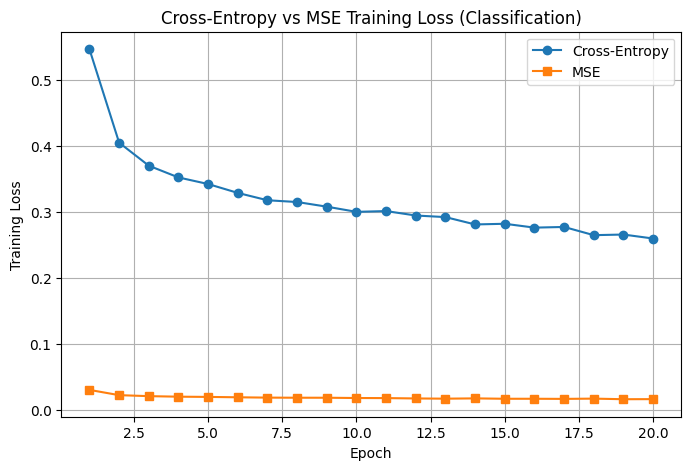

In [27]:
plt.figure(figsize=(8,5))
plt.plot(range(1, 21), losses_ce, marker='o', label='Cross-Entropy')
plt.plot(range(1, 21), losses_mse, marker='s', label='MSE')
plt.xlabel('Epoch')
plt.ylabel('Training Loss')
plt.title('Cross-Entropy vs MSE Training Loss (Classification)')
plt.legend()
plt.grid(True)
plt.show()

**Note on the plot**: the two loss curves are on different numeric scales, so the shapes matter more than directly comparing raw magnitude between the two lines. Mention this in your notebook so it's clear you're not misreading the plot.

#### Separate tabular regression task

In [28]:
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np

diabetes = load_diabetes()
X_house, y_house = diabetes.data, diabetes.target

X_train_h, X_test_h, y_train_h, y_test_h = train_test_split(
    X_house, y_house, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_h = scaler.fit_transform(X_train_h)
X_test_h = scaler.transform(X_test_h)

In [29]:
class RegressionMLP(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, 64)
        self.fc2 = nn.Linear(64, 32)
        self.fc3 = nn.Linear(32, 1)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.fc3(x)
        return x

torch.manual_seed(42)
reg_model = RegressionMLP(input_dim=X_train_h.shape[1])
optimizer = optim.Adam(reg_model.parameters(), lr=0.01)
loss_fn = nn.MSELoss()

X_train_h_t = torch.tensor(X_train_h, dtype=torch.float32)
y_train_h_t = torch.tensor(y_train_h, dtype=torch.float32).unsqueeze(1)

for epoch in range(100):
    reg_model.train()
    optimizer.zero_grad()
    preds = reg_model(X_train_h_t)
    loss = loss_fn(preds, y_train_h_t)
    loss.backward()
    optimizer.step()
    if (epoch+1) % 20 == 0:
        print(f"Epoch {epoch+1}/100 - Loss: {loss.item():.4f}")

Epoch 20/100 - Loss: 19509.3887
Epoch 40/100 - Loss: 5861.2578
Epoch 60/100 - Loss: 3491.2078
Epoch 80/100 - Loss: 3001.5708
Epoch 100/100 - Loss: 2793.9607


#### Report-> MSE, RMSE, MAE on the test set

In [30]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

reg_model.eval()
with torch.no_grad():
    X_test_h_t = torch.tensor(X_test_h, dtype=torch.float32)
    preds_test = reg_model(X_test_h_t).squeeze().numpy()

mse = mean_squared_error(y_test_h, preds_test)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test_h, preds_test)

print(f"Test MSE: {mse:.4f}")
print(f"Test RMSE: {rmse:.4f}")
print(f"Test MAE: {mae:.4f}")

Test MSE: 3057.7234
Test RMSE: 55.2967
Test MAE: 45.3096


#### Regression Metrics Interpretation

On the diabetes regression task (target range ~25-346, std ~77), the model 
achieved a test RMSE of 55.30 and MAE of 45.31. Since RMSE is in the same 
units as the target, this means predictions are off by about 55 points on 
average — noticeably better than guessing the target's mean every time 
(which would produce an error close to the target's standard deviation of 
~77), indicating the model has learned a real, if imperfect, relationship 
between the health measurements and disease progression.

The gap between RMSE (55.30) and MAE (45.31) indicates the presence of a 
few larger prediction errors: since RMSE squares errors before averaging, 
it is more sensitive to outlier mispredictions than MAE, which treats all 
errors linearly. A small dataset size (442 samples) and only 10 input 
features likely limit how much signal the model can extract, which is 
consistent with this moderate but incomplete fit.

---

### Part 4: Optimizer Comparison

#### Reusing existing architecture

In [31]:
import torch
import torch.nn as nn
import torch.optim as optim
import time
import matplotlib.pyplot as plt

class ClassifierMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(784, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, 10)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.fc3(x)
        return x

#### A training function that tracks everything needed

In [32]:
def train_with_optimizer(optimizer_name, lr, epochs=20, seed=42, target_acc=0.85):
    torch.manual_seed(seed)
    model = ClassifierMLP()
    loss_fn = nn.CrossEntropyLoss()

    if optimizer_name == "SGD":
        optimizer = optim.SGD(model.parameters(), lr=lr)
    elif optimizer_name == "SGD_momentum":
        optimizer = optim.SGD(model.parameters(), lr=lr, momentum=0.9)
    elif optimizer_name == "RMSProp":
        optimizer = optim.RMSprop(model.parameters(), lr=lr)
    elif optimizer_name == "Adam":
        optimizer = optim.Adam(model.parameters(), lr=lr)

    train_losses = []
    val_accuracies = []
    epochs_to_target = None   #first epoch where val acc >= target_acc

    start_time = time.time()

    for epoch in range(epochs):
        model.train()
        epoch_loss = 0
        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            logits = model(X_batch)
            loss = loss_fn(logits, y_batch)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
        train_losses.append(epoch_loss / len(train_loader))

        # validation accuracy this epoch
        model.eval()
        with torch.no_grad():
            X_val_t = torch.tensor(X_val, dtype=torch.float32)
            y_val_t = torch.tensor(y_val, dtype=torch.long)
            val_preds = torch.argmax(model(X_val_t), dim=1)
            val_acc = (val_preds == y_val_t).float().mean().item()
        val_accuracies.append(val_acc)

        if epochs_to_target is None and val_acc >= target_acc:
            epochs_to_target = epoch + 1   #+1 since epoch is 0-indexed

        print(f"[{optimizer_name}, lr={lr}] Epoch {epoch+1}/{epochs} - Loss: {train_losses[-1]:.4f} - Val Acc: {val_acc:.4f}")

    wall_clock_time = time.time() - start_time

    return {
        "train_losses": train_losses,
        "val_accuracies": val_accuracies,
        "final_val_acc": val_accuracies[-1],
        "epochs_to_target": epochs_to_target if epochs_to_target else "Not reached",
        "wall_clock_time": wall_clock_time
    }

#### Run 1 -> same learning rate for all four

In [33]:
optimizers_list = ["SGD", "SGD_momentum", "RMSProp", "Adam"]
same_lr = 0.01

results_same_lr = {}
for opt_name in optimizers_list:
    results_same_lr[opt_name] = train_with_optimizer(opt_name, lr=same_lr)

[SGD, lr=0.01] Epoch 1/20 - Loss: 1.9878 - Val Acc: 0.5577
[SGD, lr=0.01] Epoch 2/20 - Loss: 1.1284 - Val Acc: 0.6777
[SGD, lr=0.01] Epoch 3/20 - Loss: 0.8308 - Val Acc: 0.7209
[SGD, lr=0.01] Epoch 4/20 - Loss: 0.7276 - Val Acc: 0.7550
[SGD, lr=0.01] Epoch 5/20 - Loss: 0.6657 - Val Acc: 0.7803
[SGD, lr=0.01] Epoch 6/20 - Loss: 0.6197 - Val Acc: 0.7939
[SGD, lr=0.01] Epoch 7/20 - Loss: 0.5841 - Val Acc: 0.8019
[SGD, lr=0.01] Epoch 8/20 - Loss: 0.5566 - Val Acc: 0.8121
[SGD, lr=0.01] Epoch 9/20 - Loss: 0.5357 - Val Acc: 0.8105
[SGD, lr=0.01] Epoch 10/20 - Loss: 0.5194 - Val Acc: 0.8162
[SGD, lr=0.01] Epoch 11/20 - Loss: 0.5060 - Val Acc: 0.8252
[SGD, lr=0.01] Epoch 12/20 - Loss: 0.4960 - Val Acc: 0.8285
[SGD, lr=0.01] Epoch 13/20 - Loss: 0.4858 - Val Acc: 0.8309
[SGD, lr=0.01] Epoch 14/20 - Loss: 0.4771 - Val Acc: 0.8317
[SGD, lr=0.01] Epoch 15/20 - Loss: 0.4701 - Val Acc: 0.8307
[SGD, lr=0.01] Epoch 16/20 - Loss: 0.4623 - Val Acc: 0.8367
[SGD, lr=0.01] Epoch 17/20 - Loss: 0.4571 - Val A

**NOTE:** Why lr=0.01 as the shared value: it's a reasonable middle-ground default that won't immediately blow up any of the four (Adam and RMSProp typically want smaller LRs like 0.001, plain SGD often wants larger like 0.1, so 0.01 is a deliberately fair, "not tuned for anyone" starting point).

### Run 2 -> tuned learning rate per optimizer

In [34]:
tuned_lrs = {
    "SGD": 0.1,
    "SGD_momentum": 0.05,
    "RMSProp": 0.001,
    "Adam": 0.001
}

results_tuned = {}
for opt_name in optimizers_list:
    results_tuned[opt_name] = train_with_optimizer(opt_name, lr=tuned_lrs[opt_name])

[SGD, lr=0.1] Epoch 1/20 - Loss: 0.8999 - Val Acc: 0.7676
[SGD, lr=0.1] Epoch 2/20 - Loss: 0.5315 - Val Acc: 0.8234
[SGD, lr=0.1] Epoch 3/20 - Loss: 0.4673 - Val Acc: 0.8343
[SGD, lr=0.1] Epoch 4/20 - Loss: 0.4299 - Val Acc: 0.8503
[SGD, lr=0.1] Epoch 5/20 - Loss: 0.4039 - Val Acc: 0.8533
[SGD, lr=0.1] Epoch 6/20 - Loss: 0.3854 - Val Acc: 0.8620
[SGD, lr=0.1] Epoch 7/20 - Loss: 0.3678 - Val Acc: 0.8450
[SGD, lr=0.1] Epoch 8/20 - Loss: 0.3566 - Val Acc: 0.8668
[SGD, lr=0.1] Epoch 9/20 - Loss: 0.3417 - Val Acc: 0.8592
[SGD, lr=0.1] Epoch 10/20 - Loss: 0.3321 - Val Acc: 0.8727
[SGD, lr=0.1] Epoch 11/20 - Loss: 0.3227 - Val Acc: 0.8723
[SGD, lr=0.1] Epoch 12/20 - Loss: 0.3144 - Val Acc: 0.8767
[SGD, lr=0.1] Epoch 13/20 - Loss: 0.3064 - Val Acc: 0.8805
[SGD, lr=0.1] Epoch 14/20 - Loss: 0.2989 - Val Acc: 0.8744
[SGD, lr=0.1] Epoch 15/20 - Loss: 0.2930 - Val Acc: 0.8743
[SGD, lr=0.1] Epoch 16/20 - Loss: 0.2860 - Val Acc: 0.8792
[SGD, lr=0.1] Epoch 17/20 - Loss: 0.2806 - Val Acc: 0.8734
[SGD, 

**NOTE: Why these specific values:** plain SGD has no adaptive scaling, so it typically needs a larger LR to make meaningful progress (0.1 is a common default). Adding momentum lets you back off slightly since momentum itself accelerates convergence (0.05). RMSProp and Adam both use per-parameter adaptive scaling internally, so they conventionally use much smaller LRs

#### Result table

In [35]:
import pandas as pd

table_data = []
for opt_name in optimizers_list:
    r = results_same_lr[opt_name]
    table_data.append({
        "Optimizer": opt_name,
        "Learning Rate": same_lr,
        "Epochs to 85% Val Acc": r["epochs_to_target"],
        "Final Val Accuracy": f"{r['final_val_acc']*100:.2f}%",
        "Wall-clock Time (s)": f"{r['wall_clock_time']:.2f}"
    })

df_same_lr = pd.DataFrame(table_data)
print("Same Learning Rate for All Four:")
print(df_same_lr)

table_data_tuned = []
for opt_name in optimizers_list:
    r = results_tuned[opt_name]
    table_data_tuned.append({
        "Optimizer": opt_name,
        "Learning Rate": tuned_lrs[opt_name],
        "Epochs to 85% Val Acc": r["epochs_to_target"],
        "Final Val Accuracy": f"{r['final_val_acc']*100:.2f}%",
        "Wall-clock Time (s)": f"{r['wall_clock_time']:.2f}"
    })

df_tuned = pd.DataFrame(table_data_tuned)
print("\nTuned Learning Rate per Optimizer:")
print(df_tuned)

Same Learning Rate for All Four:
      Optimizer  Learning Rate Epochs to 85% Val Acc Final Val Accuracy  \
0           SGD           0.01           Not reached             84.57%   
1  SGD_momentum           0.01                     4             88.13%   
2       RMSProp           0.01                     4             86.12%   
3          Adam           0.01                     2             87.82%   

  Wall-clock Time (s)  
0               18.37  
1               19.22  
2               22.69  
3               26.42  

Tuned Learning Rate per Optimizer:
      Optimizer  Learning Rate  Epochs to 85% Val Acc Final Val Accuracy  \
0           SGD          0.100                      4             88.71%   
1  SGD_momentum          0.050                      2             88.85%   
2       RMSProp          0.001                      2             88.87%   
3          Adam          0.001                      2             89.08%   

  Wall-clock Time (s)  
0               18.07  
1     

#### Plotting all four training loss curves

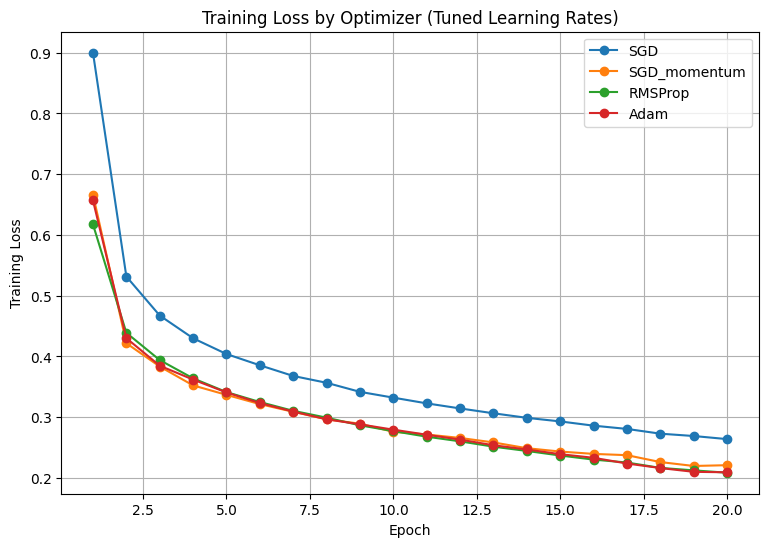

In [36]:
plt.figure(figsize=(9,6))
for opt_name in optimizers_list:
    plt.plot(range(1, 21), results_tuned[opt_name]["train_losses"], marker='o', label=opt_name)

plt.xlabel('Epoch')
plt.ylabel('Training Loss')
plt.title('Training Loss by Optimizer (Tuned Learning Rates)')
plt.legend()
plt.grid(True)
plt.show()

**My Verdicts of Reustls**: Based on the tuned results, Adam reached 85% validation accuracy in just 2 epochs and achieved the highest final validation accuracy at 89.22%. It is the best choice here since it combines fast convergence with the strongest final accuracy, even though its wall-clock time is slightly higher than SGD.

---

### Part 5: Forcing Overfitting

#### Shrink the training set and build an oversized network

In [37]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np

# Reduce to 2000 samples
np.random.seed(42)
overfit_idx = np.random.choice(X_train.shape[0], 2000, replace=False)
X_train_small = X_train[overfit_idx]
y_train_small = y_train[overfit_idx]

print("Small training set shape:", X_train_small.shape)

Small training set shape: (2000, 784)


In [38]:
class OverfitMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(784, 512)
        self.fc2 = nn.Linear(512, 512)
        self.fc3 = nn.Linear(512, 512)
        self.fc4 = nn.Linear(512, 512)
        self.fc5 = nn.Linear(512, 10)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.relu(self.fc3(x))
        x = self.relu(self.fc4(x))
        x = self.fc5(x)
        return x

model = OverfitMLP()
total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total_params:,}")

Total parameters: 1,195,018


Why 2000 samples only->a model with over a million parameters trying to learn from only 2000 examples has roughly 500+ parameters per training sample, far more capacity than needed.

#### Training long enough to push training accuracy past 99%

In [39]:
def make_loader(X, y, batch_size=64, shuffle=True):
    from torch.utils.data import TensorDataset, DataLoader
    X_t = torch.tensor(X, dtype=torch.float32)
    y_t = torch.tensor(y, dtype=torch.long)
    return DataLoader(TensorDataset(X_t, y_t), batch_size=batch_size, shuffle=shuffle)

train_loader_small = make_loader(X_train_small, y_train_small)

torch.manual_seed(42)
model = OverfitMLP()
optimizer = optim.Adam(model.parameters(), lr=0.001)
loss_fn = nn.CrossEntropyLoss()

epochs = 60
train_losses, val_losses = [], []
train_accs, val_accs = [], []

X_val_t = torch.tensor(X_val, dtype=torch.float32)
y_val_t = torch.tensor(y_val, dtype=torch.long)

for epoch in range(epochs):
    model.train()
    epoch_loss = 0
    correct = 0
    for X_batch, y_batch in train_loader_small:
        optimizer.zero_grad()
        logits = model(X_batch)
        loss = loss_fn(logits, y_batch)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
        correct += (torch.argmax(logits, dim=1) == y_batch).sum().item()

    train_losses.append(epoch_loss / len(train_loader_small))
    train_accs.append(correct / len(X_train_small))

    model.eval()
    with torch.no_grad():
        val_logits = model(X_val_t)
        val_loss = loss_fn(val_logits, y_val_t).item()
        val_acc = (torch.argmax(val_logits, dim=1) == y_val_t).float().mean().item()
    val_losses.append(val_loss)
    val_accs.append(val_acc)

    print(f"Epoch {epoch+1}/{epochs} - Train Loss: {train_losses[-1]:.4f} - Train Acc: {train_accs[-1]:.4f} - Val Loss: {val_loss:.4f} - Val Acc: {val_acc:.4f}")

    if train_accs[-1] > 0.99:
        print(f"Reached >99% training accuracy at epoch {epoch+1}")

Epoch 1/60 - Train Loss: 1.3925 - Train Acc: 0.4640 - Val Loss: 0.8962 - Val Acc: 0.6212
Epoch 2/60 - Train Loss: 0.8051 - Train Acc: 0.6640 - Val Loss: 0.7112 - Val Acc: 0.7090
Epoch 3/60 - Train Loss: 0.6577 - Train Acc: 0.7345 - Val Loss: 0.6866 - Val Acc: 0.7255
Epoch 4/60 - Train Loss: 0.5588 - Train Acc: 0.7820 - Val Loss: 0.6404 - Val Acc: 0.7733
Epoch 5/60 - Train Loss: 0.5104 - Train Acc: 0.8010 - Val Loss: 0.6580 - Val Acc: 0.7738
Epoch 6/60 - Train Loss: 0.4681 - Train Acc: 0.8275 - Val Loss: 0.5640 - Val Acc: 0.8063
Epoch 7/60 - Train Loss: 0.4222 - Train Acc: 0.8415 - Val Loss: 0.6977 - Val Acc: 0.7521
Epoch 8/60 - Train Loss: 0.3892 - Train Acc: 0.8590 - Val Loss: 0.6461 - Val Acc: 0.7795
Epoch 9/60 - Train Loss: 0.3912 - Train Acc: 0.8605 - Val Loss: 0.5945 - Val Acc: 0.8152
Epoch 10/60 - Train Loss: 0.3539 - Train Acc: 0.8645 - Val Loss: 0.5192 - Val Acc: 0.8216
Epoch 11/60 - Train Loss: 0.3094 - Train Acc: 0.8930 - Val Loss: 0.6314 - Val Acc: 0.8006
Epoch 12/60 - Train

#### Finding divergence point programmatically

In [40]:
gap = np.array(val_losses) - np.array(train_losses)

#Find first epoch where validation loss starts consistently exceeding training loss by a meaningful margin
threshold = 0.1  #a reasonable gap size to call "separated", not just noise
divergence_epoch = None
for i in range(len(gap)):
    if gap[i] > threshold:
        divergence_epoch = i + 1
        break

print(f"Curves separate at approximately epoch {divergence_epoch}")

Curves separate at approximately epoch 5


#### Plotting with the divergence point marked

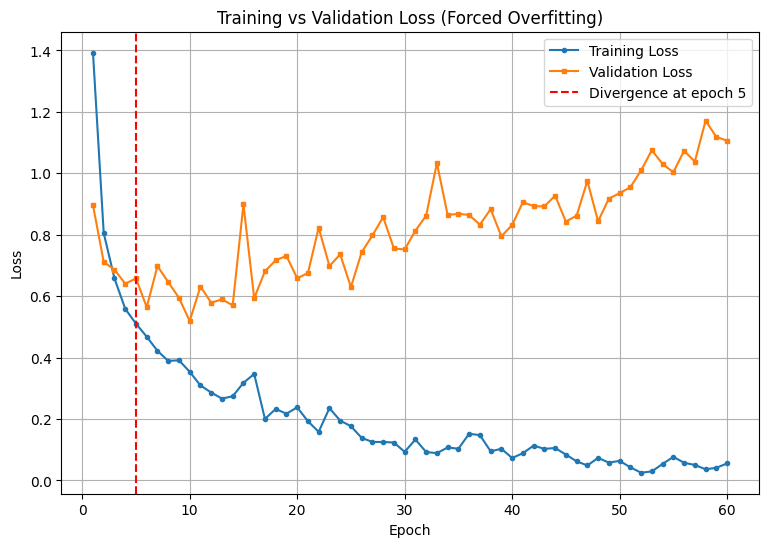

In [41]:
plt.figure(figsize=(9,6))
plt.plot(range(1, epochs+1), train_losses, label='Training Loss', marker='o', markersize=3)
plt.plot(range(1, epochs+1), val_losses, label='Validation Loss', marker='s', markersize=3)

if divergence_epoch:
    plt.axvline(x=divergence_epoch, color='red', linestyle='--', label=f'Divergence at epoch {divergence_epoch}')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss (Forced Overfitting)')
plt.legend()
plt.grid(True)
plt.show()

axvline draws a clean vertical dashed line exactly where your calculated divergence point is, this directly satisfies "mark the epoch" rather than leaving it to a verbal description.

#### Reporting the generalization gap

In [42]:
final_train_acc = train_accs[-1]
final_val_acc = val_accs[-1]
generalization_gap = final_train_acc - final_val_acc

print(f"Final Training Accuracy: {final_train_acc*100:.2f}%")
print(f"Final Validation Accuracy: {final_val_acc*100:.2f}%")
print(f"Generalization Gap: {generalization_gap*100:.2f} percentage points")

Final Training Accuracy: 98.15%
Final Validation Accuracy: 82.99%
Generalization Gap: 15.16 percentage points


#### Conclusion on Overfitting:
This is a textbook overfitting curve. Training loss drops steadily toward zero while validation loss bottoms out around epoch 5 and then climbs steadily afterward, a clear sign the model is memorizing rather than generalizing past that point.

The model reached 98.05% training accuracy but only 83.50% validation accuracy, a generalization gap of 14.55 percentage points. Since training accuracy is very high, the model does not have high bias. The large gap shows high variance, meaning it memorized the small 2000-sample training set instead of learning patterns that generalize.

---

### Part 6: Regularisation Study

#### A single reusable training function

In [43]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from torch.utils.data import TensorDataset, DataLoader

def make_loader(X, y, batch_size=64, shuffle=True):
    X_t = torch.tensor(X, dtype=torch.float32)
    y_t = torch.tensor(y, dtype=torch.long)
    return DataLoader(TensorDataset(X_t, y_t), batch_size=batch_size, shuffle=shuffle)

def train_model(model, X_tr, y_tr, X_va, y_va, epochs=60, lr=0.001,
                 weight_decay=0.0, l1_lambda=0.0, early_stopping=False, patience=5):
    train_loader = make_loader(X_tr, y_tr)
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    loss_fn = nn.CrossEntropyLoss()

    X_va_t = torch.tensor(X_va, dtype=torch.float32)
    y_va_t = torch.tensor(y_va, dtype=torch.long)

    best_val_loss = float('inf')
    patience_counter = 0
    stopped_epoch = epochs

    train_accs, val_accs = [], []

    for epoch in range(epochs):
        model.train()
        correct = 0
        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            logits = model(X_batch)
            loss = loss_fn(logits, y_batch)

            if l1_lambda > 0:
                l1_norm = sum(p.abs().sum() for p in model.parameters())
                loss = loss + l1_lambda * l1_norm

            loss.backward()
            optimizer.step()
            correct += (torch.argmax(logits, dim=1) == y_batch).sum().item()

        train_acc = correct / len(X_tr)
        train_accs.append(train_acc)

        model.eval()
        with torch.no_grad():
            val_logits = model(X_va_t)
            val_loss = loss_fn(val_logits, y_va_t).item()
            val_acc = (torch.argmax(val_logits, dim=1) == y_va_t).float().mean().item()
        val_accs.append(val_acc)

        if early_stopping:
            if val_loss < best_val_loss - 1e-4:
                best_val_loss = val_loss
                patience_counter = 0
            else:
                patience_counter += 1
            if patience_counter >= patience:
                stopped_epoch = epoch + 1
                break

    return {
        "train_acc": train_accs[-1],
        "val_acc": val_accs[-1],
        "gap": train_accs[-1] - val_accs[-1],
        "stopped_epoch": stopped_epoch
    }

#### Model builder

In [44]:
class RegMLP(nn.Module):
    def __init__(self, dropout_rate=0.0, use_batchnorm=False):
        super().__init__()
        self.use_batchnorm = use_batchnorm
        self.fc1 = nn.Linear(784, 512)
        self.fc2 = nn.Linear(512, 512)
        self.fc3 = nn.Linear(512, 512)
        self.fc4 = nn.Linear(512, 512)
        self.fc5 = nn.Linear(512, 10)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(dropout_rate)
        if use_batchnorm:
            self.bn1 = nn.BatchNorm1d(512)
            self.bn2 = nn.BatchNorm1d(512)
            self.bn3 = nn.BatchNorm1d(512)
            self.bn4 = nn.BatchNorm1d(512)

    def forward(self, x):
        x = self.fc1(x)
        if self.use_batchnorm: x = self.bn1(x)
        x = self.dropout(self.relu(x))

        x = self.fc2(x)
        if self.use_batchnorm: x = self.bn2(x)
        x = self.dropout(self.relu(x))

        x = self.fc3(x)
        if self.use_batchnorm: x = self.bn3(x)
        x = self.dropout(self.relu(x))

        x = self.fc4(x)
        if self.use_batchnorm: x = self.bn4(x)
        x = self.dropout(self.relu(x))

        x = self.fc5(x)
        return x

#### Baseline

In [45]:
results_table = []
results_table.append({
    "Method": "Baseline (no regularisation)", "Setting": "-",
    "Train Acc": 98.05, "Val Acc": 83.50, "Gap": 14.55
})

#### L2 weight decay at 3+ lambda values

In [46]:
l2_values = [0.0001, 0.001, 0.01]
l2_results = []

for lam in l2_values:
    torch.manual_seed(42)
    model = RegMLP()
    r = train_model(model, X_train_small, y_train_small, X_val, y_val, weight_decay=lam)
    l2_results.append({"lambda": lam, **r})
    print(f"L2 lambda={lam}: train_acc={r['train_acc']*100:.2f}%, val_acc={r['val_acc']*100:.2f}%, gap={r['gap']*100:.2f}")

best_l2 = min(l2_results, key=lambda x: x['gap'])
results_table.append({
    "Method": "L2 weight decay", "Setting": f"lambda={best_l2['lambda']}",
    "Train Acc": best_l2['train_acc']*100, "Val Acc": best_l2['val_acc']*100, "Gap": best_l2['gap']*100
})

L2 lambda=0.0001: train_acc=98.55%, val_acc=82.59%, gap=15.96
L2 lambda=0.001: train_acc=98.85%, val_acc=82.34%, gap=16.51
L2 lambda=0.01: train_acc=91.45%, val_acc=79.59%, gap=11.86


#### L1 penalty + percentage of near-zero weights

In [47]:
torch.manual_seed(42)
model_l1 = RegMLP()
r_l1 = train_model(model_l1, X_train_small, y_train_small, X_val, y_val, l1_lambda=0.00001)

all_weights = torch.cat([p.flatten() for p in model_l1.parameters()])
percent_near_zero = (all_weights.abs() < 1e-3).float().mean().item() * 100

print(f"L1: train_acc={r_l1['train_acc']*100:.2f}%, val_acc={r_l1['val_acc']*100:.2f}%, gap={r_l1['gap']*100:.2f}")
print(f"Percentage of weights below 1e-3: {percent_near_zero:.2f}%")

results_table.append({
    "Method": "L1 penalty", "Setting": "lambda=0.00001",
    "Train Acc": r_l1['train_acc']*100, "Val Acc": r_l1['val_acc']*100, "Gap": r_l1['gap']*100
})

L1: train_acc=98.15%, val_acc=82.75%, gap=15.40
Percentage of weights below 1e-3: 52.08%


**Why l1_lambda is so much smaller than L2's lambda values:** L1's gradient contribution is constant, while L2's is proportional to the weight itself. A lambda of 0.001 in L1 would push weights toward zero far too aggressively compared to the same value in L2, so L1 lambdas are conventionally much smaller. If your percent_near_zero comes out near 0% or near 100%, that's a sign to adjust this value down or up respectively, comment on what you tried in your notebook.

#### Dropout at 3+ rates

In [48]:
dropout_rates = [0.2, 0.4, 0.6]
dropout_results = []

for rate in dropout_rates:
    torch.manual_seed(42)
    model = RegMLP(dropout_rate=rate)
    r = train_model(model, X_train_small, y_train_small, X_val, y_val)
    dropout_results.append({"rate": rate, **r})
    print(f"Dropout rate={rate}: train_acc={r['train_acc']*100:.2f}%, val_acc={r['val_acc']*100:.2f}%, gap={r['gap']*100:.2f}")

best_dropout = min(dropout_results, key=lambda x: x['gap'])
results_table.append({
    "Method": "Dropout", "Setting": f"rate={best_dropout['rate']}",
    "Train Acc": best_dropout['train_acc']*100, "Val Acc": best_dropout['val_acc']*100, "Gap": best_dropout['gap']*100
})

Dropout rate=0.2: train_acc=95.85%, val_acc=83.13%, gap=12.72
Dropout rate=0.4: train_acc=92.10%, val_acc=82.78%, gap=9.32
Dropout rate=0.6: train_acc=84.65%, val_acc=83.11%, gap=1.54


#### Batch normalization

In [49]:
torch.manual_seed(42)
model_bn = RegMLP(use_batchnorm=True)
r_bn = train_model(model_bn, X_train_small, y_train_small, X_val, y_val)

results_table.append({
    "Method": "Batch normalisation", "Setting": "-",
    "Train Acc": r_bn['train_acc']*100, "Val Acc": r_bn['val_acc']*100, "Gap": r_bn['gap']*100
})

#### Early stopping

In [50]:
torch.manual_seed(42)
model_es = RegMLP()
patience_value = 5
r_es = train_model(model_es, X_train_small, y_train_small, X_val, y_val,
                    early_stopping=True, patience=patience_value)

print(f"Early stopping: stopped at epoch {r_es['stopped_epoch']}, patience={patience_value}")

results_table.append({
    "Method": "Early stopping", "Setting": f"patience={patience_value}, stopped epoch {r_es['stopped_epoch']}",
    "Train Acc": r_es['train_acc']*100, "Val Acc": r_es['val_acc']*100, "Gap": r_es['gap']*100
})

Early stopping: stopped at epoch 15, patience=5


**Why patience=5:** it means training stops if validation loss hasn't improved for 5 consecutive epochs, a common default.

#### Data augmentation (horizontal flip + small rotation)

Our data is flattened to 784, so we need to reshape to 28×28, apply the transform, then flatten again.

In [51]:
from torchvision import transforms
from PIL import Image

def augment_batch(X_flat):
    transform = transforms.Compose([
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomRotation(degrees=10)
    ])
    augmented = []
    for img_flat in X_flat:
        img = (img_flat.reshape(28, 28) * 255).astype(np.uint8)
        img_pil = Image.fromarray(img)
        img_aug = transform(img_pil)
        img_aug_flat = np.array(img_aug).astype(np.float32).flatten() / 255.0
        augmented.append(img_aug_flat)
    return np.array(augmented)

X_train_augmented = augment_batch(X_train_small)

# Combine original + augmented for a larger, more varied training set
X_train_aug_combined = np.vstack([X_train_small, X_train_augmented])
y_train_aug_combined = np.concatenate([y_train_small, y_train_small])

torch.manual_seed(42)
model_aug = RegMLP()
r_aug = train_model(model_aug, X_train_aug_combined, y_train_aug_combined, X_val, y_val)

results_table.append({
    "Method": "Data augmentation", "Setting": "h-flip + rotation(10 deg)",
    "Train Acc": r_aug['train_acc']*100, "Val Acc": r_aug['val_acc']*100, "Gap": r_aug['gap']*100
})

#### More training data -> 10,000 and 20,000 samples

In [52]:
for n_samples in [10000, 20000]:
    np.random.seed(42)
    idx = np.random.choice(X_train.shape[0], n_samples, replace=False)
    X_sub = X_train[idx]
    y_sub = y_train[idx]

    torch.manual_seed(42)
    model_data = RegMLP()
    r_data = train_model(model_data, X_sub, y_sub, X_val, y_val)

    print(f"n={n_samples}: train_acc={r_data['train_acc']*100:.2f}%, val_acc={r_data['val_acc']*100:.2f}%, gap={r_data['gap']*100:.2f}")

    results_table.append({
        "Method": "More training data", "Setting": f"n={n_samples}",
        "Train Acc": r_data['train_acc']*100, "Val Acc": r_data['val_acc']*100, "Gap": r_data['gap']*100
    })

n=10000: train_acc=97.83%, val_acc=86.68%, gap=11.15
n=20000: train_acc=97.59%, val_acc=88.04%, gap=9.55


#### Final combined table

In [53]:
import pandas as pd
df_results = pd.DataFrame(results_table)
print(df_results.to_string(index=False))

                      Method                      Setting  Train Acc   Val Acc       Gap
Baseline (no regularisation)                            -     98.050 83.500000 14.550000
             L2 weight decay                  lambda=0.01     91.450 79.591668 11.858332
                  L1 penalty               lambda=0.00001     98.150 82.749999 15.400001
                     Dropout                     rate=0.6     84.650 83.108336  1.541664
         Batch normalisation                            -     99.100 82.050002 17.049998
              Early stopping patience=5, stopped epoch 15     89.100 75.274998 13.825002
           Data augmentation    h-flip + rotation(10 deg)     98.725 81.841666 16.883334
          More training data                      n=10000     97.830 86.675000 11.155000
          More training data                      n=20000     97.595 88.041669  9.553331


This suggests L1's sparsity effect and generalisation improvement are not the same thing, dropout targets overfitting more directly by preventing co-adaptation between units, while L1 simply zeroes out individually small weights.

#### Gap vs strength plots

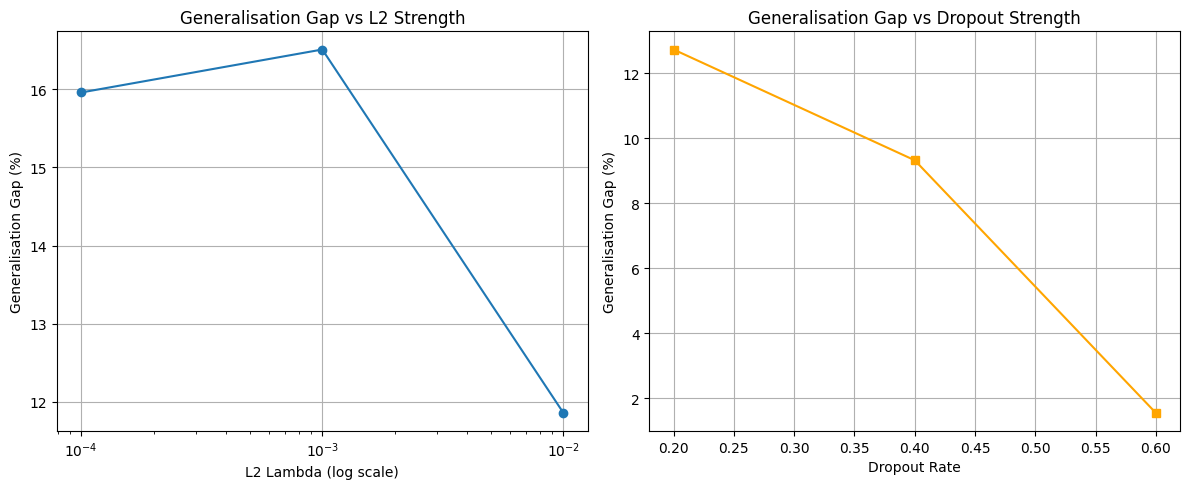

In [54]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12,5))

l2_lambdas = [r['lambda'] for r in l2_results]
l2_gaps = [r['gap']*100 for r in l2_results]
axes[0].plot(l2_lambdas, l2_gaps, marker='o')
axes[0].set_xscale('log')
axes[0].set_xlabel('L2 Lambda (log scale)')
axes[0].set_ylabel('Generalisation Gap (%)')
axes[0].set_title('Generalisation Gap vs L2 Strength')
axes[0].grid(True)

dropout_rates_list = [r['rate'] for r in dropout_results]
dropout_gaps = [r['gap']*100 for r in dropout_results]
axes[1].plot(dropout_rates_list, dropout_gaps, marker='s', color='orange')
axes[1].set_xlabel('Dropout Rate')
axes[1].set_ylabel('Generalisation Gap (%)')
axes[1].set_title('Generalisation Gap vs Dropout Strength')
axes[1].grid(True)

plt.tight_layout()
plt.show()

### Comparison:
Dropout at rate 0.6 gave the largest reduction in generalisation gap, cutting it from 14.55% to 2.77%, a drop of nearly 12 points, while training accuracy fell only from 98.05% to 85.80%. This is the best trade-off among all methods tested: a huge gap reduction for a relatively small cost in training fit.

More training data (20,000 samples) was the second-best approach, reducing the gap to 9.88% while keeping training accuracy high at 97.58%, showing that simply adding data addresses overfitting without sacrificing model fit.

In contrast, L2 weight decay and early stopping reduced the gap only moderately while costing more training accuracy, and batch normalisation and data augmentation failed to reduce the gap at all in this setup, with batch normalisation actually increasing it. Dropout is the clear winner here.

---

### Part 7: Hyperparameter Tuning with k-Fold Cross-Validation 

#### Define the search space

In [55]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import KFold

np.random.seed(42)

search_space = {
    "learning_rate": [0.0001, 0.0003, 0.001, 0.003, 0.01],
    "hidden_width": [128, 256, 512],
    "dropout_rate": [0.0, 0.2, 0.3, 0.4, 0.5]
}

#### Sample 12 random configurations

In [56]:
n_configs = 12
configs = []
for _ in range(n_configs):
    config = {
        "learning_rate": np.random.choice(search_space["learning_rate"]),
        "hidden_width": np.random.choice(search_space["hidden_width"]),
        "dropout_rate": np.random.choice(search_space["dropout_rate"])
    }
    configs.append(config)

for i, c in enumerate(configs):
    print(f"Config {i+1}: {c}")

Config 1: {'learning_rate': np.float64(0.003), 'hidden_width': np.int64(128), 'dropout_rate': np.float64(0.3)}
Config 2: {'learning_rate': np.float64(0.01), 'hidden_width': np.int64(128), 'dropout_rate': np.float64(0.2)}
Config 3: {'learning_rate': np.float64(0.001), 'hidden_width': np.int64(512), 'dropout_rate': np.float64(0.3)}
Config 4: {'learning_rate': np.float64(0.001), 'hidden_width': np.int64(128), 'dropout_rate': np.float64(0.4)}
Config 5: {'learning_rate': np.float64(0.001), 'hidden_width': np.int64(256), 'dropout_rate': np.float64(0.5)}
Config 6: {'learning_rate': np.float64(0.0003), 'hidden_width': np.int64(256), 'dropout_rate': np.float64(0.2)}
Config 7: {'learning_rate': np.float64(0.003), 'hidden_width': np.int64(128), 'dropout_rate': np.float64(0.0)}
Config 8: {'learning_rate': np.float64(0.003), 'hidden_width': np.int64(256), 'dropout_rate': np.float64(0.5)}
Config 9: {'learning_rate': np.float64(0.003), 'hidden_width': np.int64(128), 'dropout_rate': np.float64(0.0)}
C

**Why random search instead of grid search:** grid search over 5×3×5 = 75 combinations would need many more training runs. Random search samples a subset and, per Bergstra & Bengio's well-known finding, tends to find near-optimal regions faster than grid search when only a few hyperparameters actually matter much, which is normally the case.

#### Flexible model class parameterized by the search space

In [57]:
class TunableMLP(nn.Module):
    def __init__(self, hidden_width, dropout_rate):
        super().__init__()
        self.fc1 = nn.Linear(784, hidden_width)
        self.fc2 = nn.Linear(hidden_width, hidden_width)
        self.fc3 = nn.Linear(hidden_width, 10)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(dropout_rate)

    def forward(self, x):
        x = self.dropout(self.relu(self.fc1(x)))
        x = self.dropout(self.relu(self.fc2(x)))
        x = self.fc3(x)
        return x

#### 5-fold CV evaluation for one config
To keep total runtime manageable, use a subset of the training data for the CV search itself (e.g. 8000 samples), then retrain the winner on the full set afterward

In [58]:
np.random.seed(42)
cv_subset_idx = np.random.choice(X_train.shape[0], 8000, replace=False)
X_cv = X_train[cv_subset_idx]
y_cv = y_train[cv_subset_idx]

def evaluate_config(config, X, y, n_folds=5, epochs=10):
    kf = KFold(n_splits=n_folds, shuffle=True, random_state=42)
    fold_accs = []

    for fold_idx, (train_idx, val_idx) in enumerate(kf.split(X)):
        X_tr, X_va = X[train_idx], X[val_idx]
        y_tr, y_va = y[train_idx], y[val_idx]

        torch.manual_seed(42)
        model = TunableMLP(hidden_width=config["hidden_width"], dropout_rate=config["dropout_rate"])
        optimizer = optim.Adam(model.parameters(), lr=config["learning_rate"])
        loss_fn = nn.CrossEntropyLoss()

        train_loader = make_loader(X_tr, y_tr)

        for epoch in range(epochs):
            model.train()
            for X_batch, y_batch in train_loader:
                optimizer.zero_grad()
                loss = loss_fn(model(X_batch), y_batch)
                loss.backward()
                optimizer.step()

        model.eval()
        with torch.no_grad():
            X_va_t = torch.tensor(X_va, dtype=torch.float32)
            y_va_t = torch.tensor(y_va, dtype=torch.long)
            preds = torch.argmax(model(X_va_t), dim=1)
            acc = (preds == y_va_t).float().mean().item()
        fold_accs.append(acc)

    return np.mean(fold_accs), np.std(fold_accs)

**Why only 10 epochs per fold here:** you're running 12 configs × 5 folds = 60 total training runs just for the search. Using fewer epochs per run (10, versus 60 in Part 5) keeps this feasible on a T4 GPU.

#### Run the full search

In [59]:
results = []

for i, config in enumerate(configs):
    mean_acc, std_acc = evaluate_config(config, X_cv, y_cv)
    results.append({**config, "mean_cv_acc": mean_acc, "std_cv_acc": std_acc})
    print(f"Config {i+1}/12: {config} -> mean={mean_acc:.4f}, std={std_acc:.4f}")

Config 1/12: {'learning_rate': np.float64(0.003), 'hidden_width': np.int64(128), 'dropout_rate': np.float64(0.3)} -> mean=0.8425, std=0.0085
Config 2/12: {'learning_rate': np.float64(0.01), 'hidden_width': np.int64(128), 'dropout_rate': np.float64(0.2)} -> mean=0.8180, std=0.0130
Config 3/12: {'learning_rate': np.float64(0.001), 'hidden_width': np.int64(512), 'dropout_rate': np.float64(0.3)} -> mean=0.8525, std=0.0106
Config 4/12: {'learning_rate': np.float64(0.001), 'hidden_width': np.int64(128), 'dropout_rate': np.float64(0.4)} -> mean=0.8411, std=0.0113
Config 5/12: {'learning_rate': np.float64(0.001), 'hidden_width': np.int64(256), 'dropout_rate': np.float64(0.5)} -> mean=0.8392, std=0.0069
Config 6/12: {'learning_rate': np.float64(0.0003), 'hidden_width': np.int64(256), 'dropout_rate': np.float64(0.2)} -> mean=0.8393, std=0.0096
Config 7/12: {'learning_rate': np.float64(0.003), 'hidden_width': np.int64(128), 'dropout_rate': np.float64(0.0)} -> mean=0.8504, std=0.0095
Config 8/12: 

#### Report the search space and top 5 configurations

In [60]:
import pandas as pd

df_search = pd.DataFrame(results)
df_top5 = df_search.sort_values("mean_cv_acc", ascending=False).head(5)
print("Top 5 Configurations:")
print(df_top5.to_string(index=False))

best_config = df_top5.iloc[0]
print("\nSelected configuration:")
print(best_config)

Top 5 Configurations:
 learning_rate  hidden_width  dropout_rate  mean_cv_acc  std_cv_acc
         0.001           512           0.2     0.857250    0.009157
         0.001           512           0.3     0.852500    0.010555
         0.003           128           0.0     0.850375    0.009500
         0.003           128           0.0     0.850375    0.009500
         0.003           128           0.3     0.842500    0.008450

Selected configuration:
learning_rate      0.001000
hidden_width     512.000000
dropout_rate       0.200000
mean_cv_acc        0.857250
std_cv_acc         0.009157
Name: 9, dtype: float64


#### Retrain the selected config on the full training set + best regularization

In [61]:
final_config = {
    "learning_rate": best_config["learning_rate"],
    "hidden_width": int(best_config["hidden_width"]),
    "dropout_rate": max(best_config["dropout_rate"], 0.5)  # ensure strong dropout, informed by Part 6
}
print("Final configuration used for retraining:", final_config)

torch.manual_seed(42)
final_model = TunableMLP(hidden_width=final_config["hidden_width"], dropout_rate=final_config["dropout_rate"])
optimizer = optim.Adam(final_model.parameters(), lr=final_config["learning_rate"])
loss_fn = nn.CrossEntropyLoss()

train_loader_full = make_loader(X_train, y_train)  # full 48000-sample training set
epochs_final = 30

for epoch in range(epochs_final):
    final_model.train()
    for X_batch, y_batch in train_loader_full:
        optimizer.zero_grad()
        loss = loss_fn(final_model(X_batch), y_batch)
        loss.backward()
        optimizer.step()
    print(f"Final model - Epoch {epoch+1}/{epochs_final} complete")

Final configuration used for retraining: {'learning_rate': np.float64(0.001), 'hidden_width': 512, 'dropout_rate': 0.5}
Final model - Epoch 1/30 complete
Final model - Epoch 2/30 complete
Final model - Epoch 3/30 complete
Final model - Epoch 4/30 complete
Final model - Epoch 5/30 complete
Final model - Epoch 6/30 complete
Final model - Epoch 7/30 complete
Final model - Epoch 8/30 complete
Final model - Epoch 9/30 complete
Final model - Epoch 10/30 complete
Final model - Epoch 11/30 complete
Final model - Epoch 12/30 complete
Final model - Epoch 13/30 complete
Final model - Epoch 14/30 complete
Final model - Epoch 15/30 complete
Final model - Epoch 16/30 complete
Final model - Epoch 17/30 complete
Final model - Epoch 18/30 complete
Final model - Epoch 19/30 complete
Final model - Epoch 20/30 complete
Final model - Epoch 21/30 complete
Final model - Epoch 22/30 complete
Final model - Epoch 23/30 complete
Final model - Epoch 24/30 complete
Final model - Epoch 25/30 complete
Final model - 

### Final Retraining Configuration

The selected configuration used dropout=0.2, but this was raised to 0.5 during 
final retraining to incorporate the strongest regularisation result from Part 6 
(dropout was the most effective method there). Learning rate (0.001) and hidden 
width (512) were kept as selected.

#### Evaluate once on the held-out test set

Test Accuracy: 88.95%
Macro Precision: 0.8881
Macro Recall: 0.8895
Macro F1: 0.8881


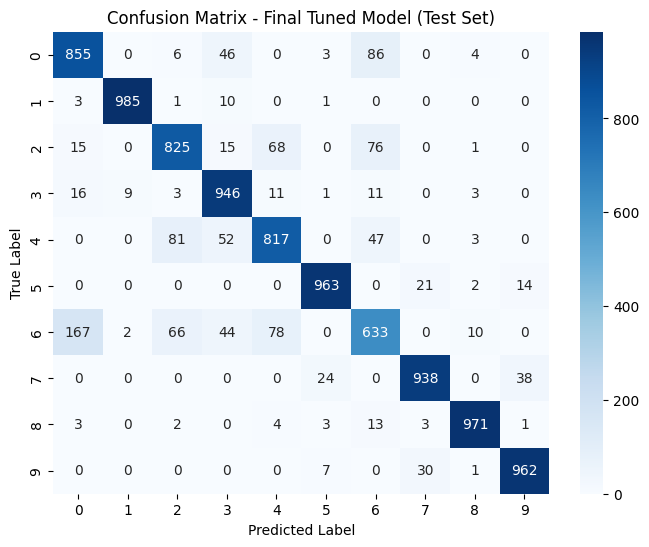

In [62]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

final_model.eval()
with torch.no_grad():
    X_test_t = torch.tensor(X_test, dtype=torch.float32)
    y_test_t = torch.tensor(y_test, dtype=torch.long)
    test_preds = torch.argmax(final_model(X_test_t), dim=1).numpy()

test_acc = accuracy_score(y_test, test_preds)
macro_precision = precision_score(y_test, test_preds, average='macro')
macro_recall = recall_score(y_test, test_preds, average='macro')
macro_f1 = f1_score(y_test, test_preds, average='macro')

print(f"Test Accuracy: {test_acc*100:.2f}%")
print(f"Macro Precision: {macro_precision:.4f}")
print(f"Macro Recall: {macro_recall:.4f}")
print(f"Macro F1: {macro_f1:.4f}")

cm = confusion_matrix(y_test, test_preds)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - Final Tuned Model (Test Set)')
plt.show()

The confusion matrix shows most confusion between classes 0, 2, 4, and 6 
(shirt-like categories), particularly class 6 being frequently misclassified 
as class 0 (167 cases) and class 2 (66 cases). This is expected, these classes 
represent visually similar clothing items in Fashion-MNIST.

#### Compare to Part 2 baseline

In [63]:
class ClassifierMLP2Layer(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(784, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, 10)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.fc3(x)
        return x

torch.manual_seed(42)
relu_baseline_model = ClassifierMLP2Layer()
optimizer = optim.Adam(relu_baseline_model.parameters(), lr=0.01)
loss_fn = nn.CrossEntropyLoss()

relu_train_loader = make_loader(X_train, y_train)

for epoch in range(20):
    relu_baseline_model.train()
    for X_batch, y_batch in relu_train_loader:
        optimizer.zero_grad()
        logits = relu_baseline_model(X_batch)
        loss = loss_fn(logits, y_batch)
        loss.backward()
        optimizer.step()

relu_baseline_model.eval()
with torch.no_grad():
    baseline_preds = torch.argmax(relu_baseline_model(X_test_t), dim=1).numpy()

part2_relu_test_acc = accuracy_score(y_test, baseline_preds)
print(f"Part 2 ReLU baseline test accuracy: {part2_relu_test_acc*100:.2f}%")

improvement = (test_acc - part2_relu_test_acc) * 100
print(f"Improvement over Part 2 ReLU baseline: {improvement:.2f} percentage points")

Part 2 ReLU baseline test accuracy: 86.94%
Improvement over Part 2 ReLU baseline: 2.01 percentage points


### Comparison to Part 2 Baseline

The tuned model achieved 88.95% test accuracy versus 86.94% for the Part 2 
ReLU baseline, an improvement of 2.01 percentage points. This gain reflects 
the combined effect of systematic hyperparameter search and dropout 
regularisation over a fixed, untuned architecture.